## Task 1- PCA on Iris Dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

iris_data = load_iris()
features = iris_data.data
labels = iris_data.target

scaled = StandardScaler().fit_transform(features)
pca_model = PCA(n_components=2)
iris_pca = pca_model.fit_transform(scaled)

print("Explained variance (2 PCs):")
print("PC1 =", round(pca_model.explained_variance_ratio_[0], 4))
print("PC2 =", round(pca_model.explained_variance_ratio_[1], 4))


Explained variance (2 PCs):
PC1 = 0.7296
PC2 = 0.2285


## Task 2- PCA Visualization

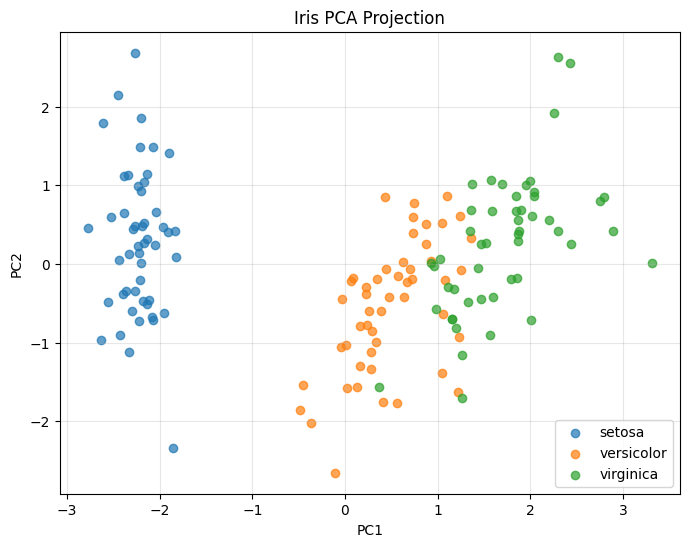

In [2]:
species_names = iris_data.target_names

plt.figure(figsize=(8,6))
for idx, sp in enumerate(species_names):
    mask = labels == idx
    plt.scatter(iris_pca[mask,0], iris_pca[mask,1], label=sp, alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Iris PCA Projection")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Task 3- PCA on Synthetic Zomato Data

Variance ratios per PC: [0.148  0.1329 0.1195]
Cumulative variance: [0.148  0.281  0.4004]


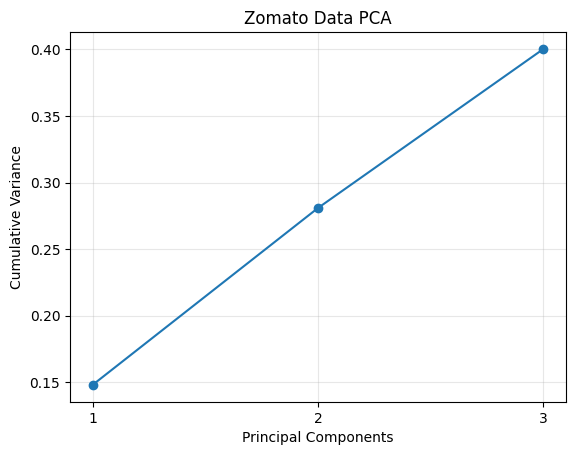

In [3]:
rng = np.random.default_rng(42)
zomato = rng.normal(size=(150,10))

pca_z = PCA(n_components=3)
zomato_reduced = pca_z.fit_transform(zomato)
cum_var = np.cumsum(pca_z.explained_variance_ratio_)

print("Variance ratios per PC:", np.round(pca_z.explained_variance_ratio_,4))
print("Cumulative variance:", np.round(cum_var,4))

plt.plot(range(1,4), cum_var, marker="o")
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Variance")
plt.title("Zomato Data PCA")
plt.xticks([1,2,3])
plt.grid(alpha=0.3)
plt.show()


## Task 4- KMeans on PCA_Reduced Iris

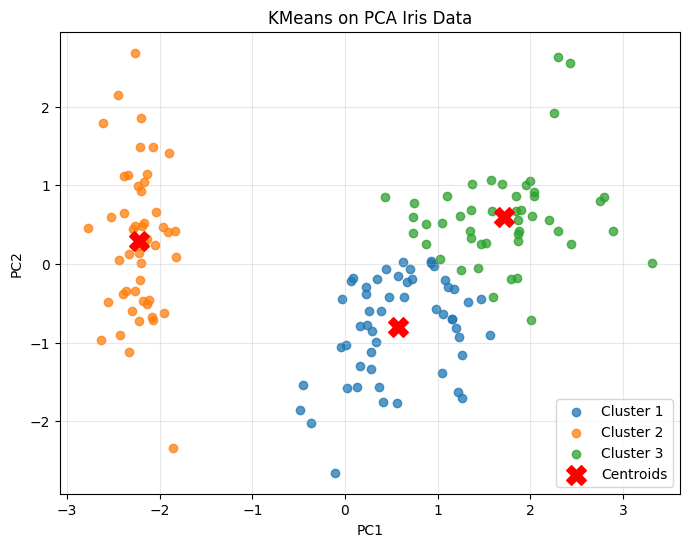

Cluster centroids:
[[ 0.5726 -0.8072]
 [-2.2248  0.2889]
 [ 1.721   0.6029]]


In [4]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = km.fit_predict(iris_pca)
centers = km.cluster_centers_

plt.figure(figsize=(8,6))
for cid in range(3):
    mask = cluster_labels == cid
    plt.scatter(iris_pca[mask,0], iris_pca[mask,1], label=f"Cluster {cid+1}", alpha=0.75)

plt.scatter(centers[:,0], centers[:,1], marker="X", s=200, c="red", label="Centroids")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans on PCA Iris Data")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Cluster centroids:")
print(np.round(centers,4))


## Task 5- Silhouette Score

In [5]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(iris_pca, cluster_labels)
print("Silhouette Score =", round(sil_score, 4))


Silhouette Score = 0.5092
